In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

# Chargement
daily = pd.read_csv("../data/processed/daily_features.csv")
# On ne garde que les jours où tu as couru (TRIMP > 0)
data_ml = daily[daily["TRIMP"] > 0].copy()

# Sélection des features pour les modèles
features = ["distance_km", "duree_min", "fc_moyenne", "vitesse_moy", "CTL", "ATL", "TSB"]
X = data_ml[features].dropna()

# Normalisation (obligatoire pour le K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data prête pour le ML : {X.shape[0]} séances d'entraînement")

Data prête pour le ML : 313 séances d'entraînement


Profil moyen par cluster :
         distance_km  duree_min  fc_moyenne  vitesse_moy    CTL    ATL    TSB
cluster                                                                      
0              13.66      64.03      154.20        13.17  51.05  72.58 -21.54
1               4.09      21.73      146.56        12.32  34.38  31.18   3.20
2               7.82      32.39      161.77        14.67  40.29  44.97  -4.69


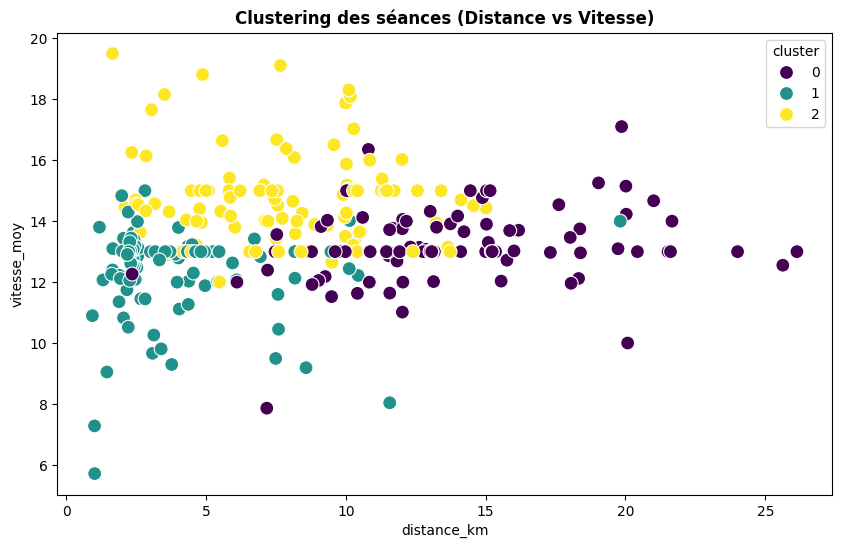

In [2]:
# On cherche 3 clusters (ex: Récupération, Endurance, Intensité)
kmeans = KMeans(n_clusters=3, random_state=42)
data_ml["cluster"] = kmeans.fit_predict(X_scaled)

# Analyse des clusters
cluster_profile = data_ml.groupby("cluster")[features].mean().round(2)
print("Profil moyen par cluster :")
print(cluster_profile)

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_ml, x="distance_km", y="vitesse_moy", hue="cluster", palette="viridis", s=100)
plt.title("Clustering des séances (Distance vs Vitesse)", fontweight="bold")
plt.show()

16 séances détectées comme anomalies (potentiel surmenage)


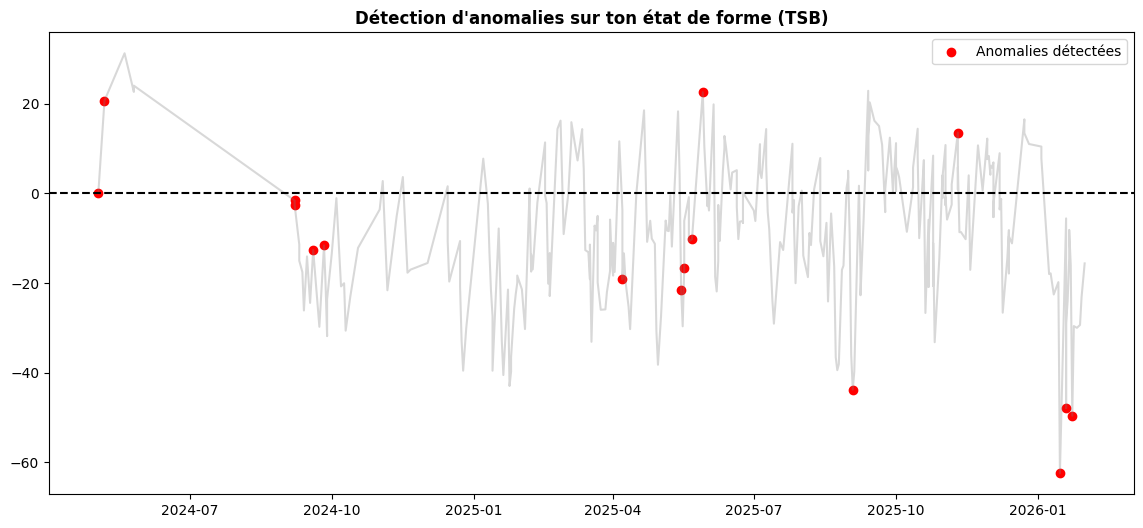

In [3]:
# Contamination = 5% (on cherche les 5% de séances les plus "bizarres")
iso_forest = IsolationForest(contamination=0.05, random_state=42)
data_ml["anomaly"] = iso_forest.fit_predict(X_scaled)

# -1 = Anomalie, 1 = Normal
anomalies = data_ml[data_ml["anomaly"] == -1]

print(f"{len(anomalies)} séances détectées comme anomalies (potentiel surmenage)")

# Visualisation des anomalies
plt.figure(figsize=(14, 6))
plt.plot(pd.to_datetime(data_ml["date"]), data_ml["TSB"], color="gray", alpha=0.3)
plt.scatter(pd.to_datetime(anomalies["date"]), anomalies["TSB"], color="red", label="Anomalies détectées")
plt.axhline(0, color="black", linestyle="--")
plt.title("Détection d'anomalies sur ton état de forme (TSB)", fontweight="bold")
plt.legend()
plt.show()

In [5]:
data_ml.to_csv("../data/processed/ml_results.csv", index=False)
print("Résultats ML sauvegardés dans data/processed/ml_results.csv")

Résultats ML sauvegardés dans data/processed/ml_results.csv
